# SHAP Interpretability Analysis

## Scientific objective

Quantify feature contributions to the XGBoost model predictions using SHAP (SHapley Additive exPlanations). This notebook computes SHAP values for the held-out test set and generates publication-quality interpretability figures.

## Background

SHAP provides consistent, model-agnostic explanations by estimating each feature's contribution to individual predictions based on Shapley values from cooperative game theory.

## Methodology

- Load the finalized feature matrix and target values.
- Retrain or load a fitted XGBoost regressor for interpretation.
- Compute SHAP values using a TreeExplainer.
- Generate summary, bar, dependence, and descriptor-only plots and save them as PNG and PDF at 300 dpi.

In [ ]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from pathlib import Path

# Use relative, portable paths
ROOT = Path("..")
X = pd.read_csv(ROOT / "data" / "processed" / "X_combined.csv")
y = pd.read_csv(ROOT / "data" / "processed" / "y_pIC50.csv").squeeze()

print(X.shape)
print(y.shape)

c:\Users\Khushwant Singh\Desktop\Anti leishmenia drug properties\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(5457, 1035)
(5457,)


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Training the Best Performing Model

The XGBoost model was retrained to enable SHAP-based interpretation of molecular descriptors and fingerprint features contributing to anti-leishmanial activity predictions.

In [3]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=1
)

xgb.fit(
    X_train,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## SHAP Explainability Analysis

SHAP (SHapley Additive exPlanations) values were calculated to quantify the contribution of each feature to model predictions and identify molecular properties associated with anti-leishmanial activity.

In [ ]:
explainer = shap.TreeExplainer(xgb)

# Obtain SHAP values for the test set. For regressors this returns an array
shap_values = explainer.shap_values(X_test)

print(np.array(shap_values).shape)

(1092, 1035)


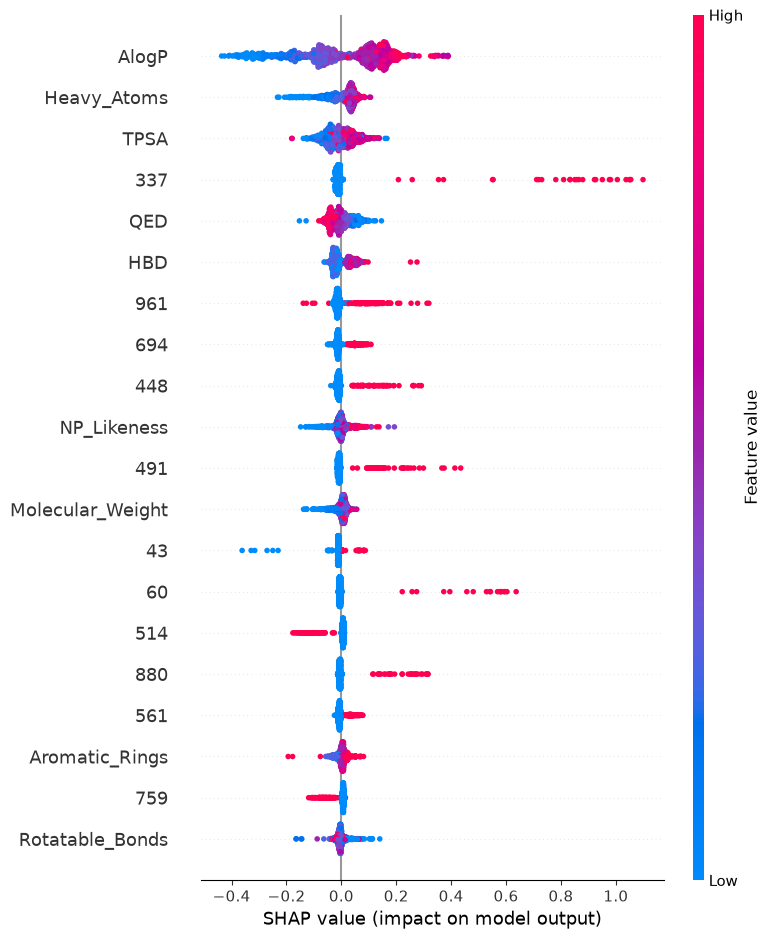

In [ ]:
# Create and save the SHAP summary plot (be explicit about the figure)
shap.summary_plot(shap_values, X_test, show=False)
fig = plt.gcf()
fig.savefig(Path('..') / 'figures' / 'shap_summary_plot.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(Path('..') / 'figures' / 'shap_summary_plot.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.close(fig)

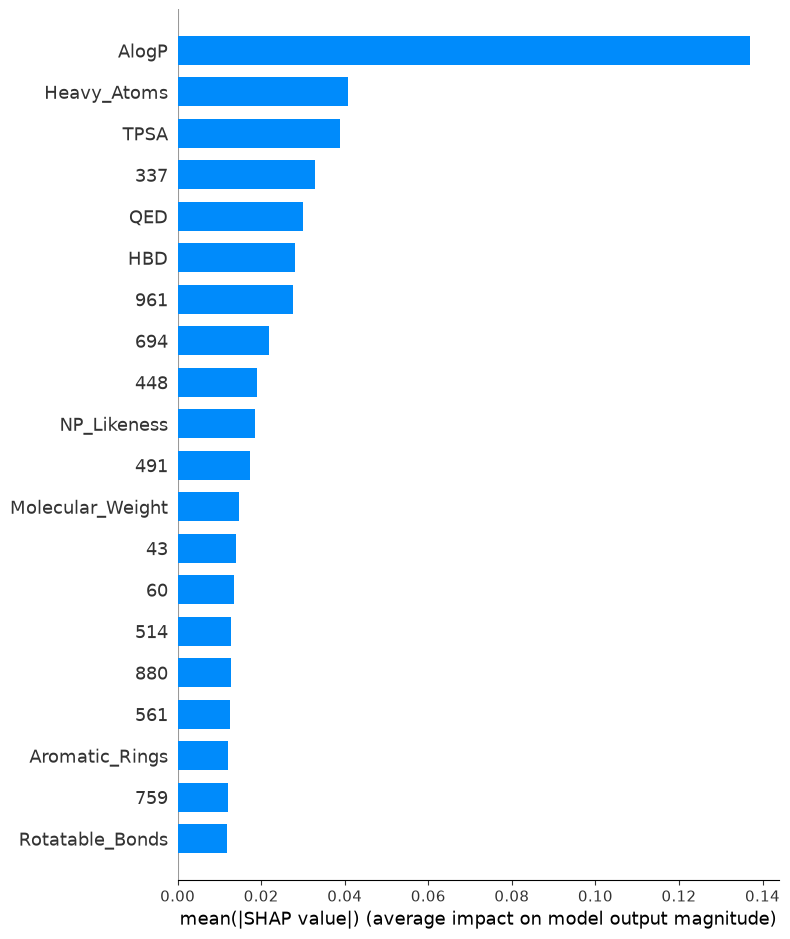

In [ ]:
# Bar-type SHAP importance plot
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
fig = plt.gcf()
fig.savefig(Path('..') / 'figures' / 'shap_summary_barplot.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(Path('..') / 'figures' / 'shap_summary_barplot.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.close(fig)

In [8]:
feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean_Abs_SHAP": np.abs(shap_values).mean(axis=0)
})

feature_importance = feature_importance.sort_values(
    "Mean_Abs_SHAP",
    ascending=False
)

feature_importance.head(20)

,Feature,Mean_Abs_SHAP
1,AlogP,0.136988
9,Heavy_Atoms,0.040825
2,TPSA,0.038942
348,337,0.032907
7,QED,0.029968
4,HBD,0.028089
972,961,0.027612
705,694,0.021865
459,448,0.018911
10,NP_Likeness,0.018586


In [9]:
feature_importance.to_csv(
    "../results/shap_feature_importance.csv",
    index=False
)

In [10]:
descriptor_names = [
    "Molecular_Weight",
    "AlogP",
    "TPSA",
    "HBA",
    "HBD",
    "RO5_Violations",
    "Rotatable_Bonds",
    "QED",
    "Aromatic_Rings",
    "Heavy_Atoms",
    "NP_Likeness"
]

feature_importance[
    feature_importance["Feature"].isin(
        descriptor_names
    )
]

,Feature,Mean_Abs_SHAP
1,AlogP,0.136988
9,Heavy_Atoms,0.040825
2,TPSA,0.038942
7,QED,0.029968
4,HBD,0.028089
10,NP_Likeness,0.018586
0,Molecular_Weight,0.014728
8,Aromatic_Rings,0.012006
6,Rotatable_Bonds,0.011897
3,HBA,0.006229


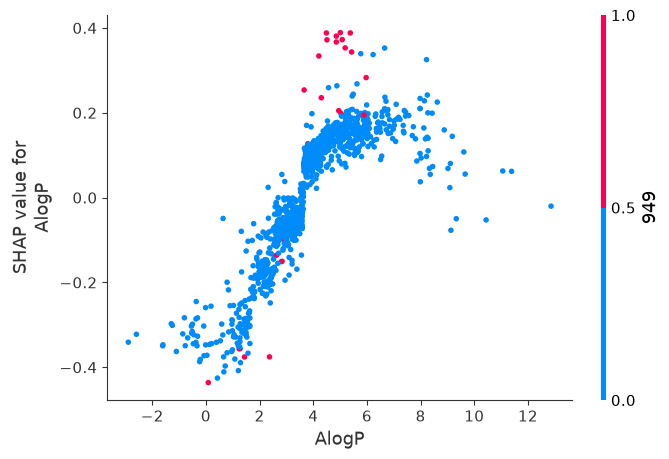

In [ ]:
# Dependence plot for AlogP
shap.dependence_plot('AlogP', shap_values, X_test, show=False)
fig = plt.gcf()
fig.savefig(Path('..') / 'figures' / 'shap_dependence_alogp.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(Path('..') / 'figures' / 'shap_dependence_alogp.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.close(fig)

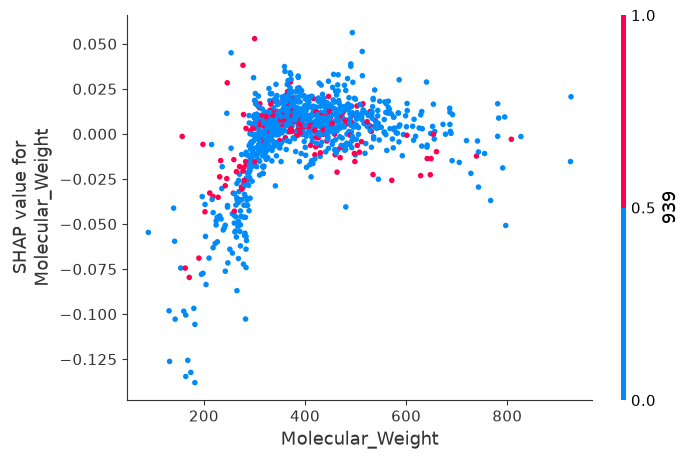

In [ ]:
# Dependence plot for Molecular Weight
shap.dependence_plot('Molecular_Weight', shap_values, X_test, show=False)
fig = plt.gcf()
fig.savefig(Path('..') / 'figures' / 'shap_dependence_mw.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(Path('..') / 'figures' / 'shap_dependence_mw.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.close(fig)

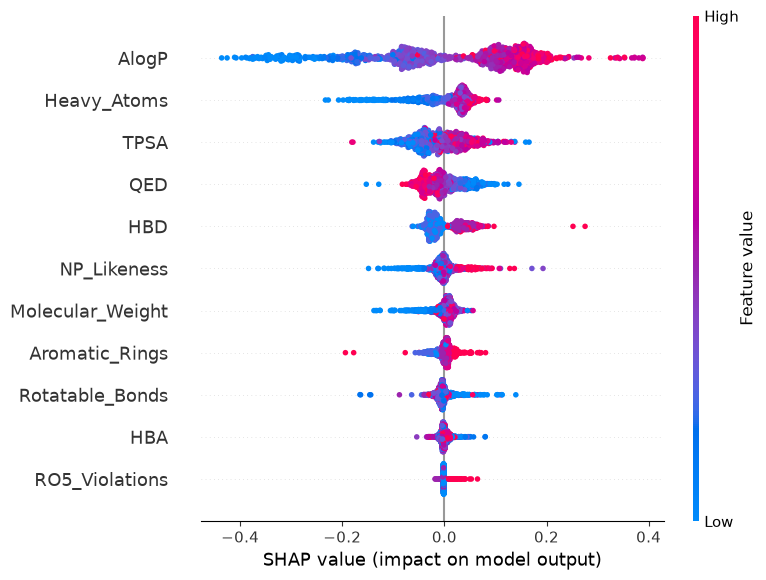

In [ ]:
descriptor_names = [
    'Molecular_Weight',
    'AlogP',
    'TPSA',
    'HBA',
    'HBD',
    'RO5_Violations',
    'Rotatable_Bonds',
    'QED',
    'Aromatic_Rings',
    'Heavy_Atoms',
    'NP_Likeness'
]

# Ensure all descriptor names are present
present_desc = [c for c in descriptor_names if c in X_test.columns]
desc_idx = [X_test.columns.get_loc(col) for col in present_desc]

# Descriptor-only SHAP values and summary plot
shap_desc = shap_values[:, desc_idx]
X_test_desc = X_test[present_desc]
shap.summary_plot(shap_desc, X_test_desc, show=False)
fig = plt.gcf()
fig.savefig(Path('..') / 'figures' / 'shap_descriptors_summary.png', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(Path('..') / 'figures' / 'shap_descriptors_summary.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.close(fig)

In [14]:
descriptor_shap = pd.DataFrame({
    "Feature": descriptor_names,
    "Mean_Abs_SHAP": np.abs(shap_desc).mean(axis=0)
}).sort_values("Mean_Abs_SHAP", ascending=False)

descriptor_shap

,Feature,Mean_Abs_SHAP
1,AlogP,0.136988
9,Heavy_Atoms,0.040825
2,TPSA,0.038942
7,QED,0.029968
4,HBD,0.028089
10,NP_Likeness,0.018586
0,Molecular_Weight,0.014728
8,Aromatic_Rings,0.012006
6,Rotatable_Bonds,0.011897
3,HBA,0.006229


## SHAP Interpretation of Descriptor Features

SHAP analysis showed that AlogP was the most influential molecular descriptor in the model, indicating that lipophilicity played the strongest role in anti-leishmanial activity prediction. Heavy atom count, TPSA, QED, HBD, and NP-Likeness also contributed to model predictions, while RO5 violations and HBA had comparatively low importance. The results suggest that activity is driven by a combination of physicochemical properties rather than a single descriptor alone.